In [1]:
import ccxt
print(ccxt.exchanges)

exchange = ccxt.bitget()

['alp', 'alpaca', 'apex', 'arkham', 'ascendex', 'aster', 'backpack', 'bequant', 'bigone', 'binance', 'binancecoinm', 'binanceus', 'binanceusdm', 'bingx', 'bit2c', 'bitbank', 'bitbns', 'bitfinex', 'bitflyer', 'bitget', 'bithumb', 'bitmart', 'bitmex', 'bitopro', 'bitrue', 'bitso', 'bitstamp', 'bitteam', 'bittrade', 'bitvavo', 'blockchaincom', 'blofin', 'btcbox', 'btcmarkets', 'btcturk', 'bullish', 'bybit', 'bydfi', 'cex', 'coinbase', 'coinbaseadvanced', 'coinbaseexchange', 'coinbaseinternational', 'coincatch', 'coincheck', 'coinex', 'coinmate', 'coinmetro', 'coinone', 'coinsph', 'coinspot', 'cryptocom', 'cryptomus', 'deepcoin', 'defx', 'delta', 'deribit', 'derive', 'digifinex', 'dydx', 'exmo', 'fmfwio', 'foxbit', 'gate', 'gateio', 'gemini', 'hashkey', 'hibachi', 'hitbtc', 'hollaex', 'htx', 'huobi', 'hyperliquid', 'independentreserve', 'indodax', 'kraken', 'krakenfutures', 'kucoin', 'kucoinfutures', 'latoken', 'lbank', 'luno', 'mercado', 'mexc', 'modetrade', 'myokx', 'ndax', 'novadax', 'o

In [4]:
import pandas as pd
import time
from datetime import datetime, timedelta

def to_dataframe(candles: list[list[float]]) -> pd.DataFrame:
    df = pd.DataFrame(candles, columns=['datetime', 'open', 'high', 'low', 'close', 'volume'])
    df['datetime'] = pd.to_datetime(df['datetime'], unit='ms')
    df = df.set_index('datetime').sort_index()
    
    return df

def fetch_ohlcv_range(symbol: str, timeframe: str, start_ts_ms: int, end_ts_ms: int) -> pd.DataFrame:
    all_candles: list[list[float]] = []
    current_since = start_ts_ms
    limit = 100

    while current_since < end_ts_ms:
        candles = exchange.fetch_ohlcv(
            symbol=symbol,
            timeframe=timeframe,
            since=current_since,
            limit=limit
        )
        if not candles:
            break

        all_candles.extend(candles)

        last_ts = candles[-1][0]
        if last_ts >= end_ts_ms:
            break

        current_since = last_ts + 1

        time.sleep(1)

    return to_dataframe(all_candles)


since = int((datetime.now() - timedelta(days=30)).timestamp() * 1000)
end = int(datetime.now().timestamp() * 1000)
symbol = 'SOL/USDT'
timeframe = '15m'

df = fetch_ohlcv_range(
    symbol=symbol,
    timeframe=timeframe,
    start_ts_ms=since,
    end_ts_ms=end
)
print(df.head())
df.to_csv(f'{symbol.replace('/', '_')}_{timeframe}_{since}_{end}.csv')

                       open    high     low   close     volume
datetime                                                      
2026-01-23 01:15:00  128.32  128.57  128.27  128.42  2342.0048
2026-01-23 01:30:00  128.42  128.78  128.33  128.71  3278.7293
2026-01-23 01:45:00  128.71  128.92  128.63  128.90  2657.2998
2026-01-23 02:00:00  128.90  128.96  128.56  128.78  3024.3740
2026-01-23 02:15:00  128.78  128.81  128.40  128.50   484.7823


In [3]:
from datetime import timedelta

import numpy as np
import pandas as pd

df_btc_1m = pd.read_csv('BTC_USDT_1m_1768676055355_1771268055355.csv', index_col='datetime')
df_btc_15m = pd.read_csv('BTC_USDT_15m_1768676577928_1771268577928.csv', index_col='datetime')

df_btc_1m.index = pd.to_datetime(df_btc_1m.index)
df_btc_15m.index = pd.to_datetime(df_btc_15m.index)

print(df_btc_1m)
print(df_btc_15m)

df_btc_15m['delta_volume'] = None

for time_15m in df_btc_15m.index:
    start_time = time_15m
    end_time = time_15m + timedelta(minutes=15)

    candles_1m = df_btc_1m[
        (df_btc_1m.index >= start_time) &
        (df_btc_1m.index < end_time)
    ]

    if len(candles_1m) < 15:
        continue

    period_delta = 0.0

    for candle in candles_1m.itertuples():
        difference = candle.close - candle.open

        if difference > 0:
            period_delta += candle.volume
        elif difference < 0:
            period_delta -= candle.volume

    df_btc_15m.at[time_15m, 'delta_volume'] = period_delta

df_btc_15m = df_btc_15m.dropna(subset=['delta_volume'])
df_btc_15m['delta_volume_acc'] = df_btc_15m['delta_volume'].cumsum()
df_btc_15m.to_csv('BTC_USDT_15m_1768676577928_1771268577928_deltas.csv')

print(df_btc_15m)


                         open      high       low     close    volume
datetime                                                             
2026-01-17 18:55:00  95420.31  95427.17  95420.31  95427.16  0.116846
2026-01-17 18:56:00  95427.16  95427.17  95427.16  95427.16  0.526718
2026-01-17 18:57:00  95427.16  95439.16  95419.38  95430.68  3.123455
2026-01-17 18:58:00  95430.68  95430.68  95428.28  95428.28  0.315820
2026-01-17 18:59:00  95428.28  95428.29  95428.28  95428.28  0.004057
...                       ...       ...       ...       ...       ...
2026-02-16 18:54:00  67991.39  67993.85  67991.38  67992.96  0.146834
2026-02-16 18:55:00  67992.96  67992.96  67959.79  67969.52  3.696729
2026-02-16 18:56:00  67969.52  67981.81  67935.78  67935.79  0.913339
2026-02-16 18:57:00  67935.79  67939.09  67866.67  67867.90  9.399382
2026-02-16 18:58:00  67867.90  67882.32  67857.32  67879.75  0.745461

[43204 rows x 5 columns]
                         open      high       low     close     

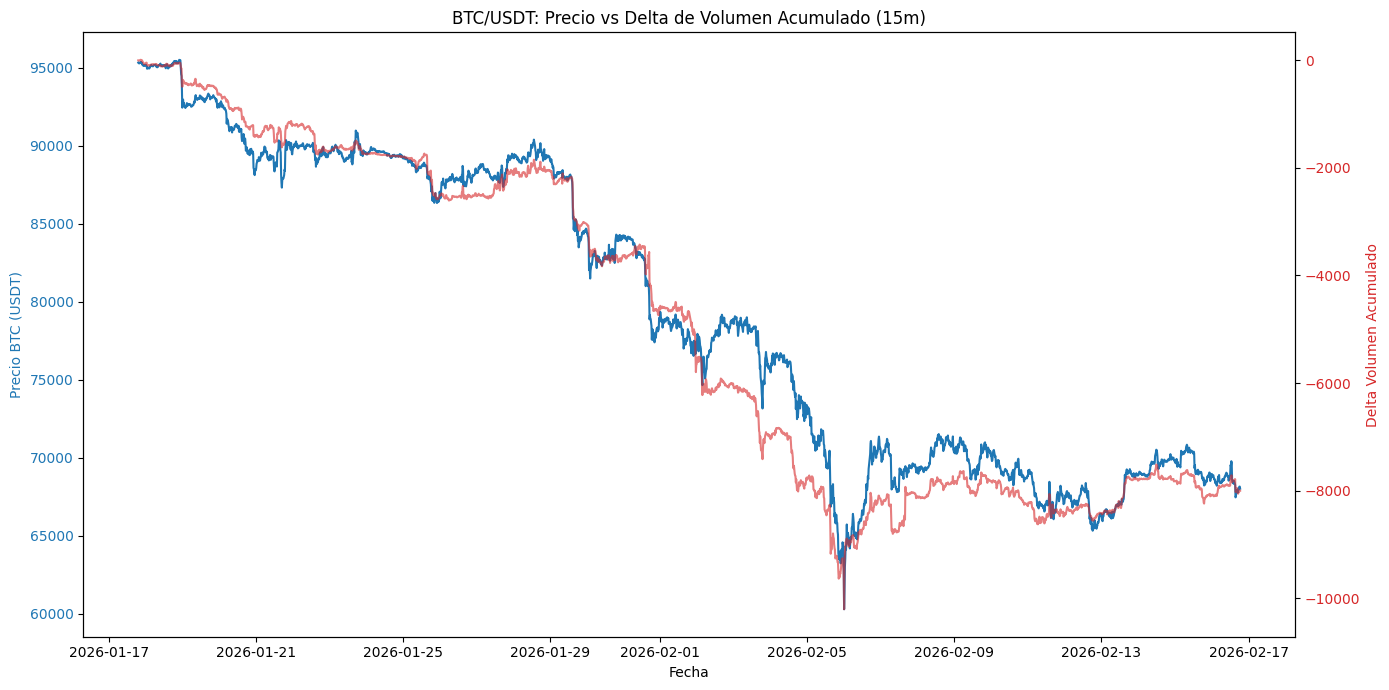

In [6]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(14, 7))

ax1.set_xlabel('Fecha')
ax1.set_ylabel('Precio BTC (USDT)', color='tab:blue')
ax1.plot(df_btc_15m.index, df_btc_15m['close'], color='tab:blue', label='Precio Close')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()
ax2.set_ylabel('Delta Volumen Acumulado', color='tab:red')
ax2.plot(df_btc_15m.index, df_btc_15m['delta_volume_acc'], color='tab:red', alpha=0.6, label='Delta Vol Acc')
ax2.tick_params(axis='y', labelcolor='tab:red')

plt.title('BTC/USDT: Precio vs Delta de Volumen Acumulado (15m)')
fig.tight_layout()
plt.savefig('btc_deltavol.png')
plt.show()